In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('default')
sns.set_theme()

%matplotlib inline

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [6]:
nav['date'] = pd.to_datetime(nav['date'])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [7]:
print("Unique Funds:", nav['amfi_code'].nunique())

Unique Funds: 40


In [8]:
nav_trend = (
    nav.groupby('date')['nav']
    .mean()
    .reset_index()
)

nav_trend.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


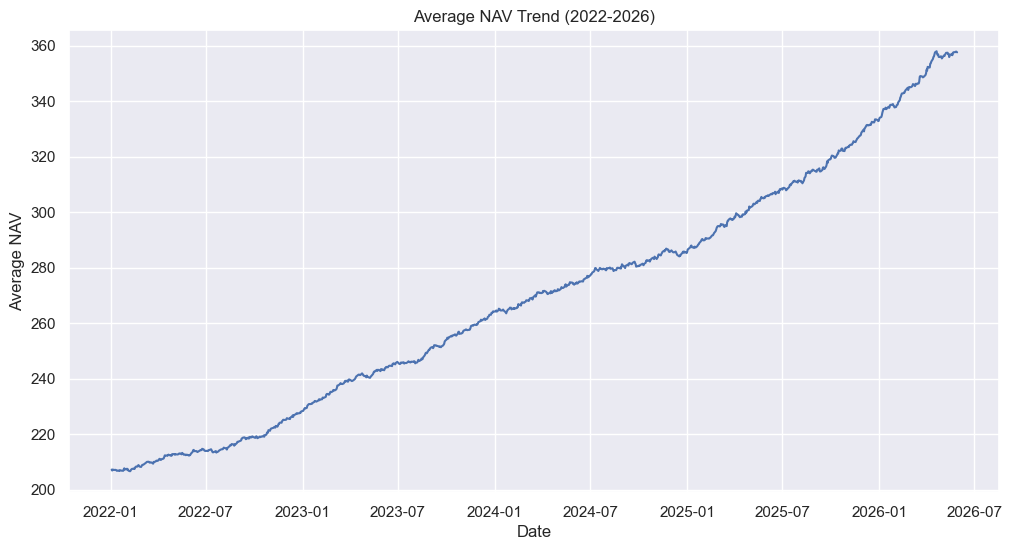

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nav_trend['date'], nav_trend['nav'])
plt.title('Average NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('Average NAV')
plt.show()

### Insight 1
The average NAV across mutual fund schemes showed an overall upward trend from 2022 onward, indicating long-term growth in fund values despite short-term market fluctuations.

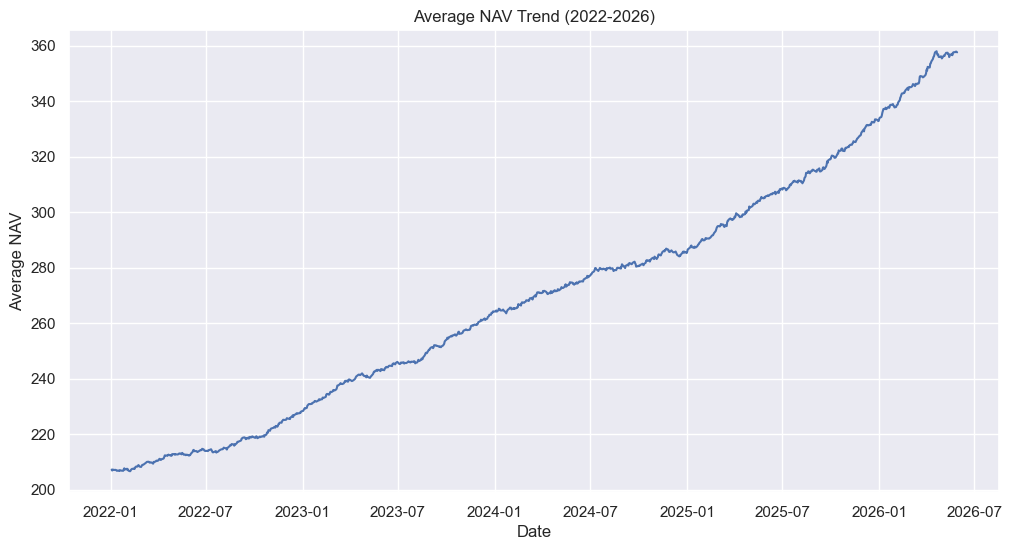

In [10]:
plt.figure(figsize=(12,6))
plt.plot(nav_trend['date'], nav_trend['nav'])
plt.title('Average NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('Average NAV')

plt.savefig('../report/nav_trend.png', bbox_inches='tight')
plt.show()

In [11]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'live_nav_125497.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [12]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [13]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [14]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [15]:
aum['date'] = pd.to_datetime(aum['date'])

aum['date'].dt.year.value_counts().sort_index()

date
2022    20
2023    20
2024    30
2025    20
Name: count, dtype: int64

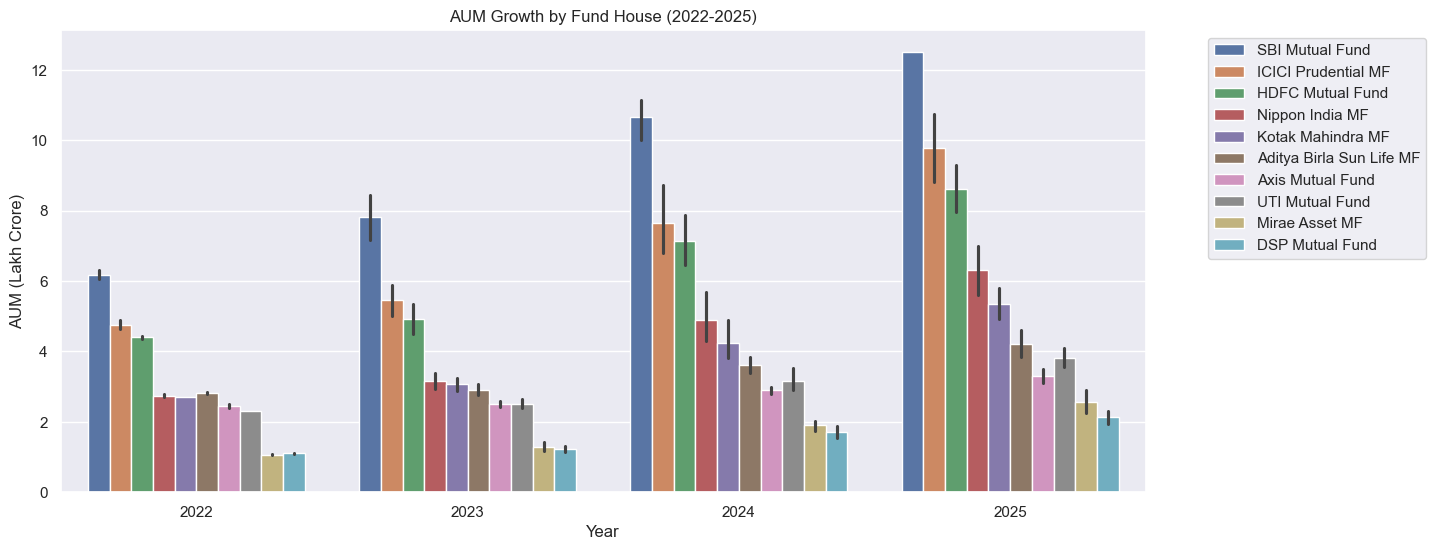

In [16]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x=aum['date'].dt.year,
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Insight 2: AUM Growth Analysis

SBI Mutual Fund maintained market leadership throughout 2022–2025, growing its AUM from approximately ₹6.2 lakh crore to ₹12.5 lakh crore. The overall mutual fund industry experienced significant growth during the period, with ICICI Prudential MF and HDFC Mutual Fund remaining the strongest competitors. Most fund houses recorded steady increases in AUM, indicating rising investor participation and expanding mutual fund adoption in India.

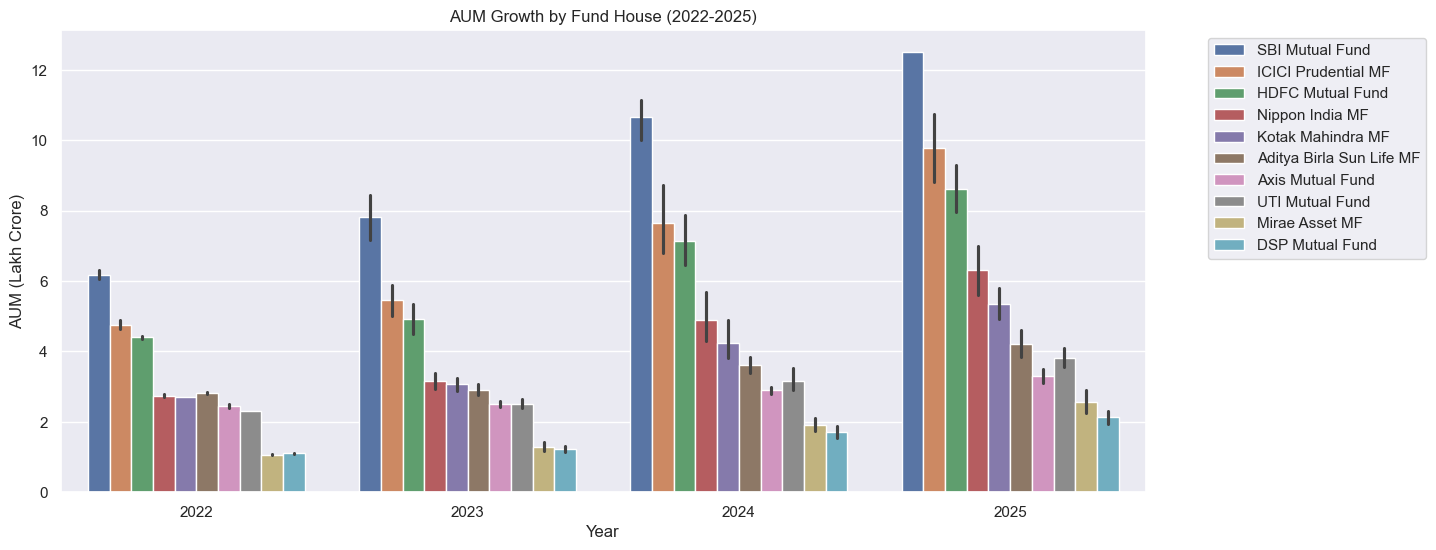

In [17]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x=aum['date'].dt.year,
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../report/aum_growth.png', bbox_inches='tight')
plt.show()

In [18]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [19]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [20]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [21]:
sip['month'] = pd.to_datetime(sip['month'])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


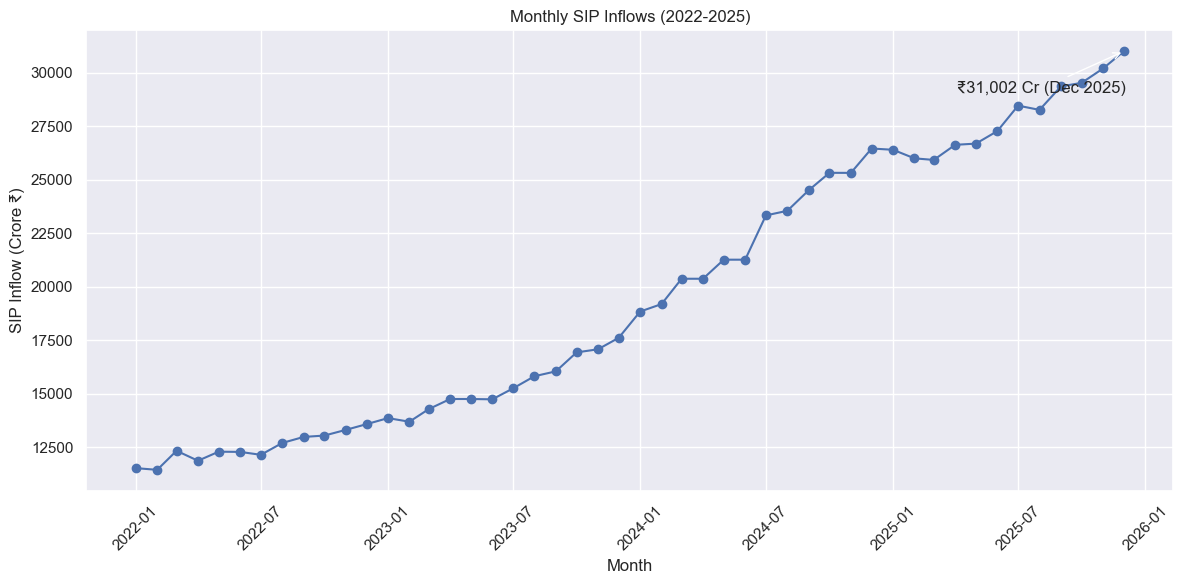

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

max_idx = sip['sip_inflow_crore'].idxmax()

plt.annotate(
    '₹31,002 Cr (Dec 2025)',
    xy=(sip.loc[max_idx, 'month'],
        sip.loc[max_idx, 'sip_inflow_crore']),
    xytext=(-120, -30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.title('Monthly SIP Inflows (2022-2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore ₹)')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../report/sip_inflow_trend.png', bbox_inches='tight')

plt.show()

In [23]:
sip.loc[sip['sip_inflow_crore'].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

### Insight 3: SIP Inflow Trend

Monthly SIP inflows increased steadily from approximately ₹11,500 crore in 2022 to a record ₹31,002 crore in December 2025. The trend reflects growing retail investor participation, increasing awareness of systematic investing, and strong confidence in mutual funds as a long-term wealth creation vehicle.

In [24]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [25]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [26]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [27]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


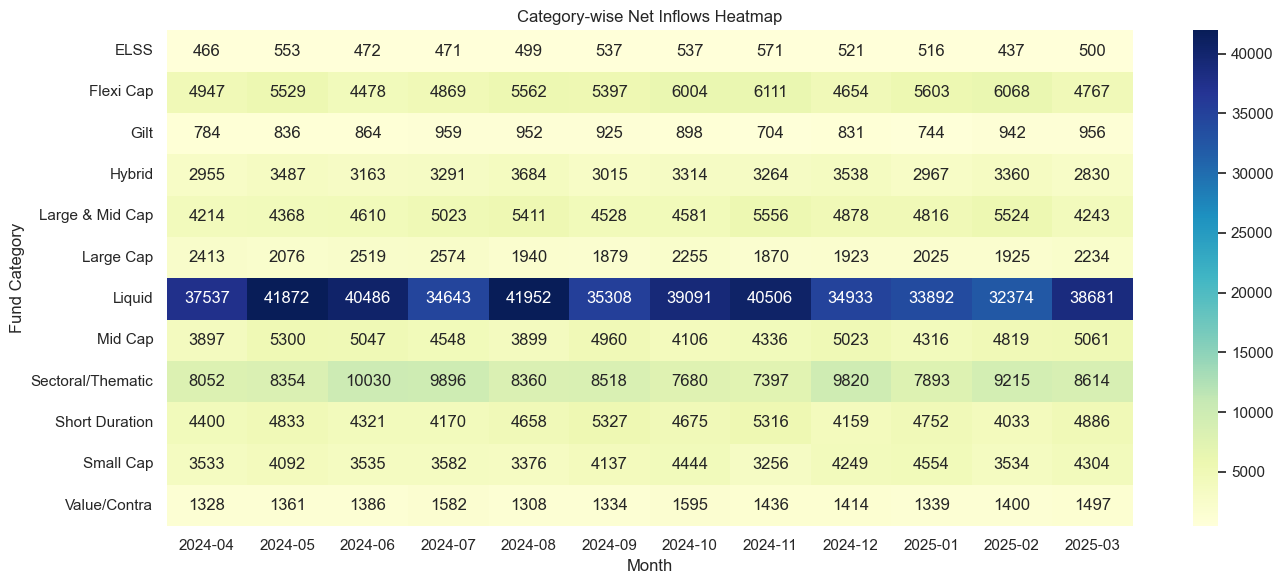

In [28]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Category-wise Net Inflows Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.tight_layout()
plt.show()

### Insight 4: Category-wise Net Inflows

Liquid funds attracted the highest inflows throughout the period, reflecting strong demand for short-term liquidity management. Among equity-oriented categories, Sectoral/Thematic and Flexi Cap funds received the strongest investor interest, while ELSS and Value/Contra funds recorded comparatively lower inflows. The heatmap highlights clear differences in investor preferences across mutual fund categories.

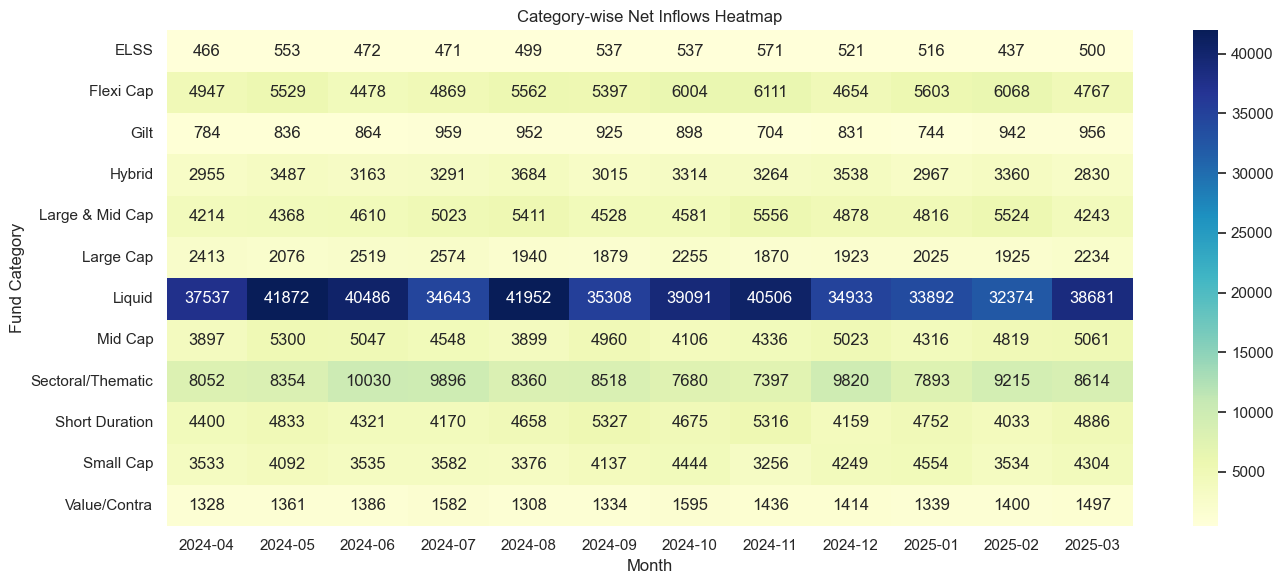

In [29]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Category-wise Net Inflows Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.tight_layout()

plt.savefig('../report/category_inflows_heatmap.png',
            bbox_inches='tight')

plt.show()

In [30]:
investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [31]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [32]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [33]:
age_dist = investor['age_group'].value_counts()

age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

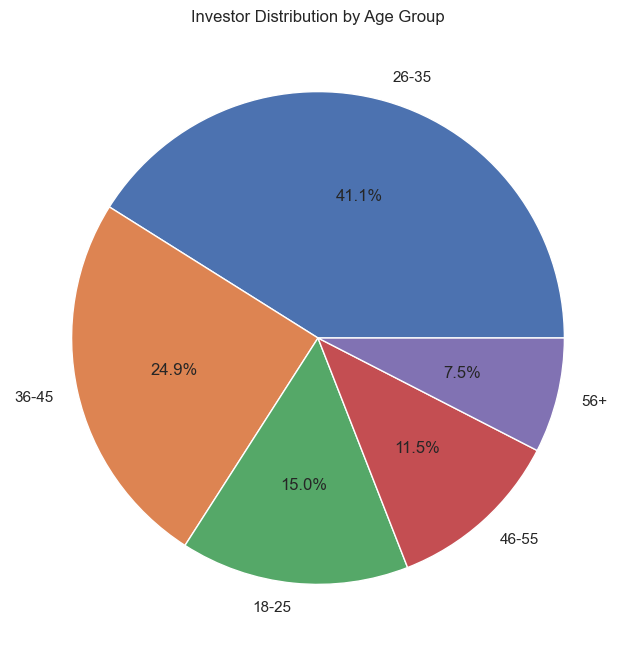

In [34]:
plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Distribution by Age Group')

plt.show()

### Insight 5: Investor Age Distribution

The 26–35 age group accounts for the largest share of mutual fund investors (41.1%), highlighting strong participation from young professionals. The 36–45 segment represents the second-largest investor base, while investors above 55 years contribute a relatively smaller share. This indicates that mutual fund adoption is strongest among working-age individuals focused on long-term wealth creation.

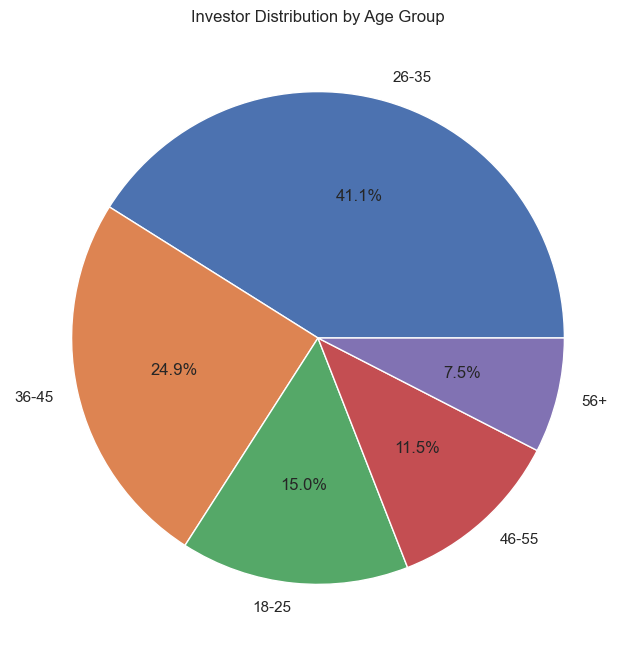

In [35]:
plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Distribution by Age Group')

plt.savefig(
    '../report/age_group_distribution.png',
    bbox_inches='tight'
)

plt.show()

In [36]:
gender_dist = investor['gender'].value_counts()

gender_dist

gender
Male      21809
Female    10969
Name: count, dtype: int64

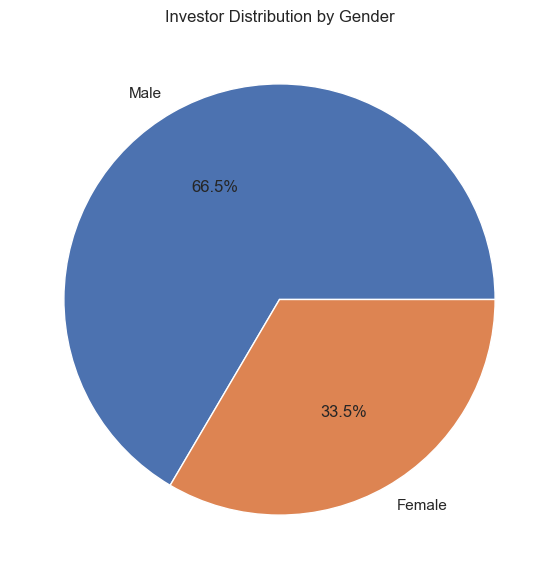

In [37]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Distribution by Gender')

plt.show()

### Insight 6: Gender Distribution

Male investors account for 66.5% of the investor base, while female investors represent 33.5%. Although male participation remains dominant, the sizeable share of female investors reflects increasing financial inclusion and growing awareness of mutual fund investing among women.

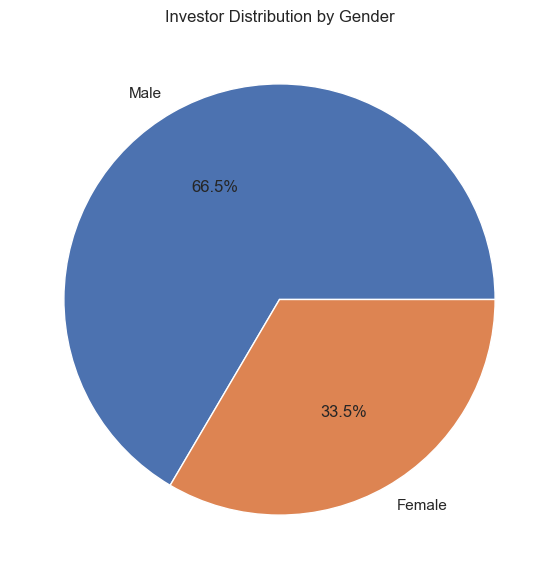

In [38]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Distribution by Gender')

plt.savefig(
    '../report/gender_distribution.png',
    bbox_inches='tight'
)

plt.show()

In [39]:
investor.groupby('age_group')['amount_inr'].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
18-25,4916.0,108144.709520,151765.866810,401.0,3038.75,17553.0,190858.0,590635.0
26-35,13463.0,107821.452722,150251.623816,400.0,3151.50,18523.0,190901.5,597498.0
36-45,8146.0,107003.133808,150402.614486,400.0,3170.00,17457.0,188750.0,591658.0
46-55,3779.0,107278.769251,150601.035638,400.0,3144.00,17425.0,188516.5,587530.0
56+,2474.0,105613.105497,148465.191753,406.0,3302.50,20396.5,179326.5,587757.0


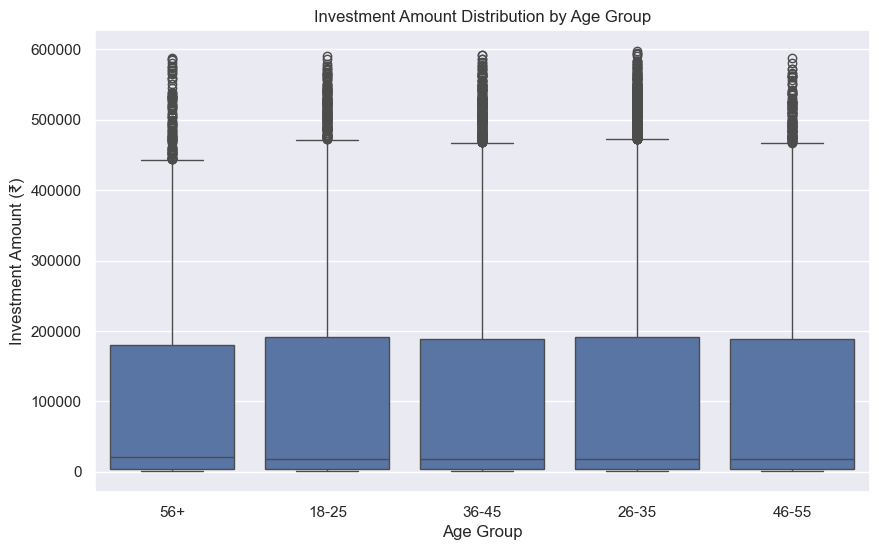

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Investment Amount (₹)')

plt.show()

### Insight 7: Investment Amount Distribution by Age Group

Investment amount distributions are broadly similar across age groups, suggesting that investor age does not strongly influence transaction size. All age segments contain high-value outliers, indicating the presence of large investors across the demographic spectrum. The primary difference between age groups is investor count rather than individual investment amount.

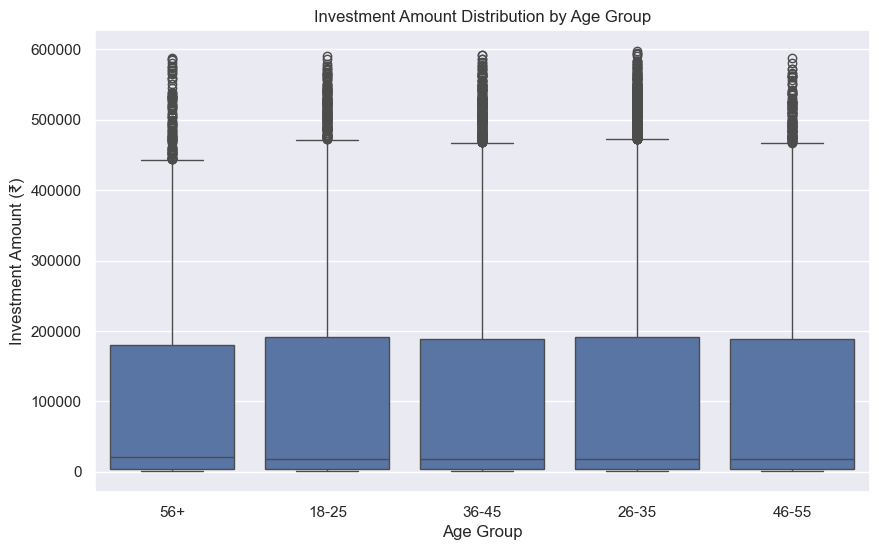

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Investment Amount (₹)')

plt.savefig(
    '../report/investment_amount_age_group.png',
    bbox_inches='tight'
)

plt.show()

In [42]:
state_investment = (
    investor.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

state_investment.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

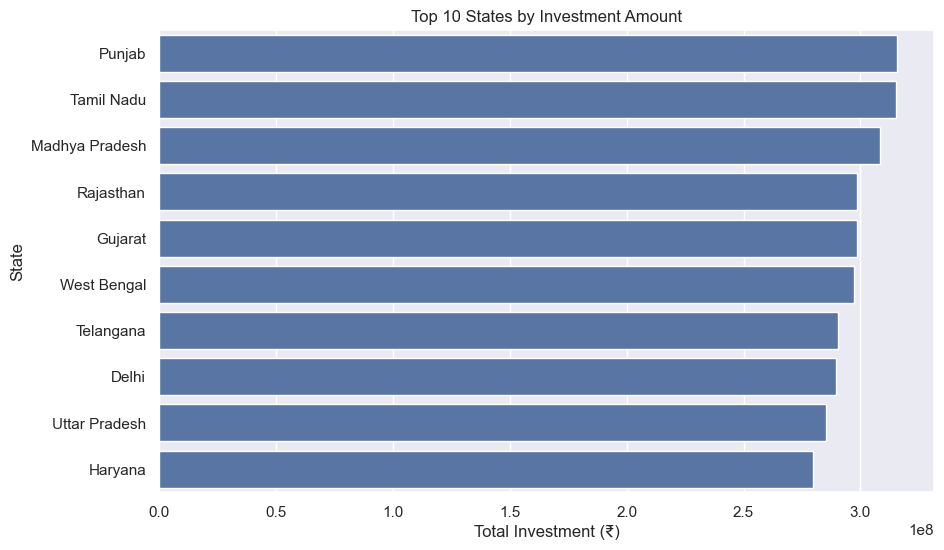

In [43]:
top_states = state_investment.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 States by Investment Amount')
plt.xlabel('Total Investment (₹)')
plt.ylabel('State')

plt.show()

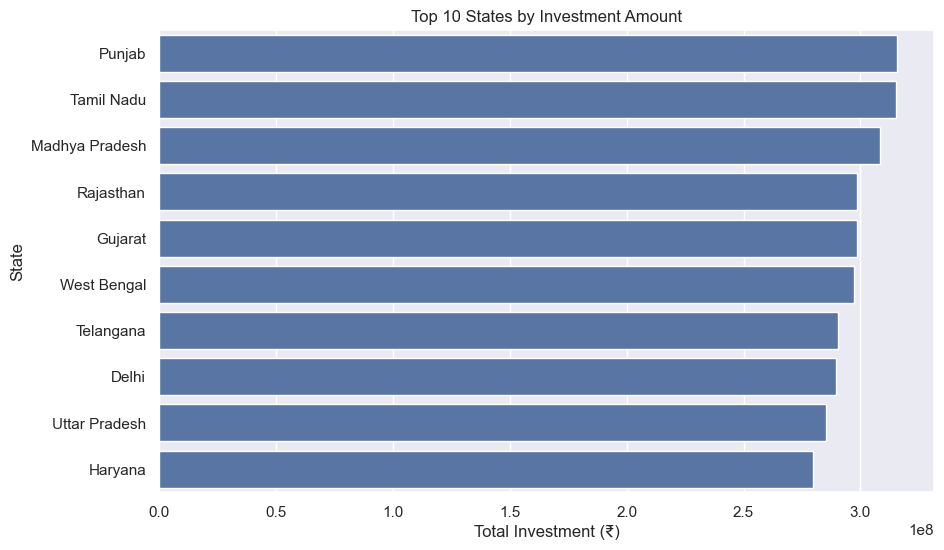

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 States by Investment Amount')
plt.xlabel('Total Investment (₹)')
plt.ylabel('State')

plt.savefig(
    '../report/state_investment_distribution.png',
    bbox_inches='tight'
)

plt.show()

### Insight 8: State-wise Investment Distribution

Punjab, Tamil Nadu, and Madhya Pradesh recorded the highest total investment amounts in the dataset. The top ten states contributed a significant share of overall investments, highlighting the geographic concentration of mutual fund participation across major Indian states.

In [45]:
city_tier_dist = investor['city_tier'].value_counts()

city_tier_dist

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

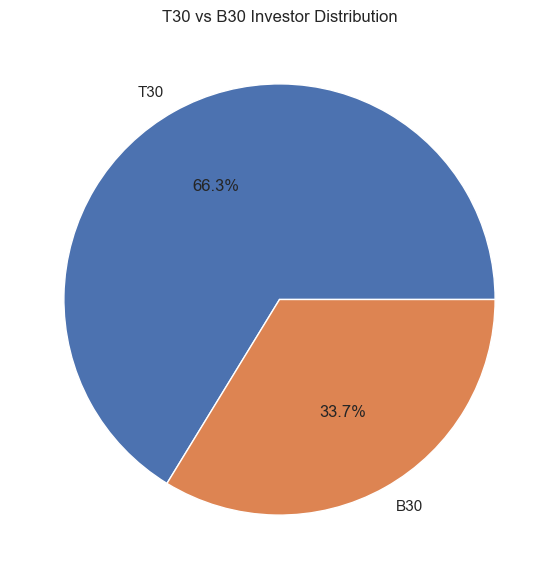

In [46]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier_dist,
    labels=city_tier_dist.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.show()

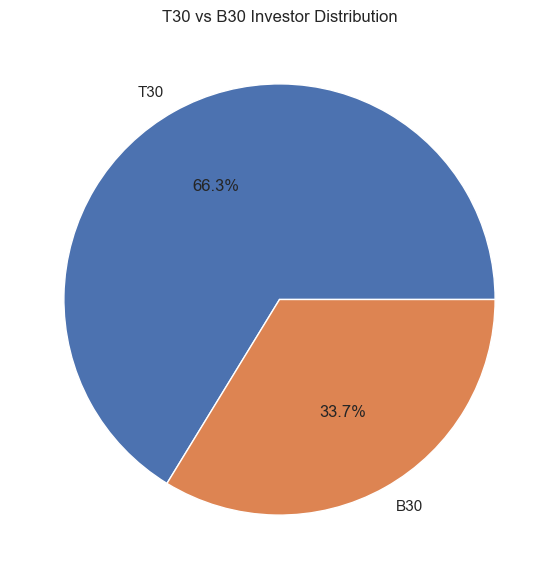

In [47]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier_dist,
    labels=city_tier_dist.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.savefig(
    '../report/t30_b30_distribution.png',
    bbox_inches='tight'
)

plt.show()

### Insight 9: T30 vs B30 Distribution

The comparison between T30 (Top 30 cities) and B30 (Beyond Top 30 cities) investors highlights the geographic spread of mutual fund adoption. A growing share of investors from B30 cities indicates increasing penetration of mutual funds beyond major metropolitan regions.

In [48]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [49]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [50]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [51]:
folio['month'] = pd.to_datetime(folio['month'])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


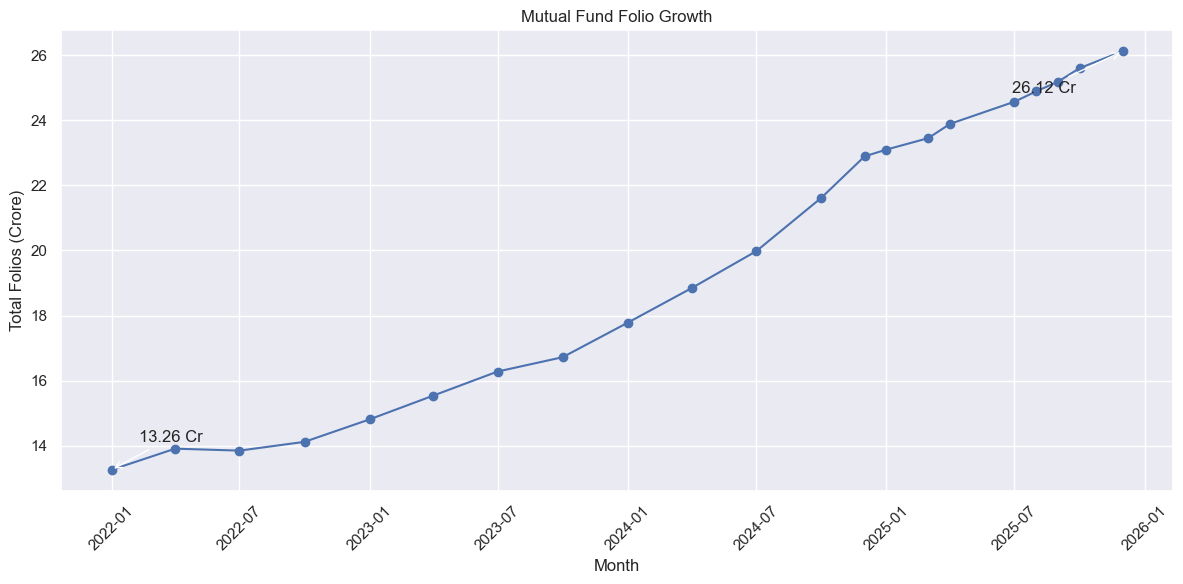

In [52]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.annotate(
    '13.26 Cr',
    xy=(folio['month'].iloc[0],
        folio['total_folios_crore'].iloc[0]),
    xytext=(20,20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.annotate(
    '26.12 Cr',
    xy=(folio['month'].iloc[-1],
        folio['total_folios_crore'].iloc[-1]),
    xytext=(-80,-30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.title('Mutual Fund Folio Growth')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/folio_growth.png',
    bbox_inches='tight'
)

plt.show()

In [53]:
print("Start:", folio['total_folios_crore'].iloc[0])
print("End:", folio['total_folios_crore'].iloc[-1])

Start: 13.26
End: 26.12


### Insight 10: Mutual Fund Folio Growth

Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, representing approximately 97% growth. The sharp acceleration during 2024–2025 reflects rising retail participation, increasing financial awareness, and broader adoption of mutual funds across India.

In [54]:
nav['amfi_code'].nunique()

40

In [55]:
nav['amfi_code'].unique()[:15]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092])

In [56]:
selected_funds = nav['amfi_code'].unique()[:10]

nav_subset = nav[nav['amfi_code'].isin(selected_funds)]

nav_pivot = nav_subset.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [57]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [58]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


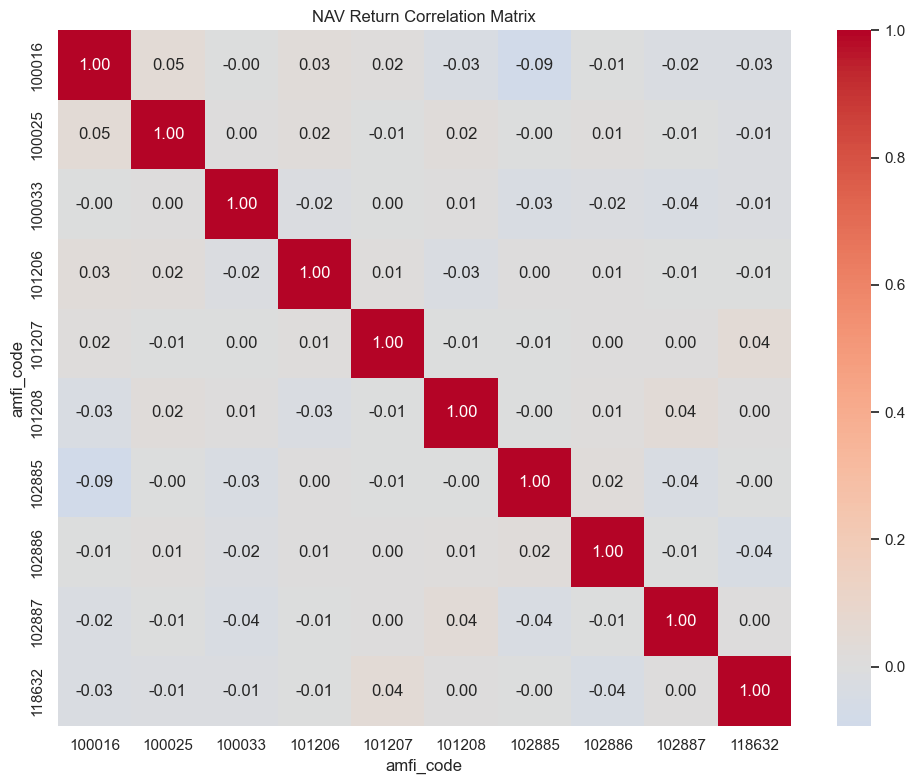

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')

plt.tight_layout()

plt.show()

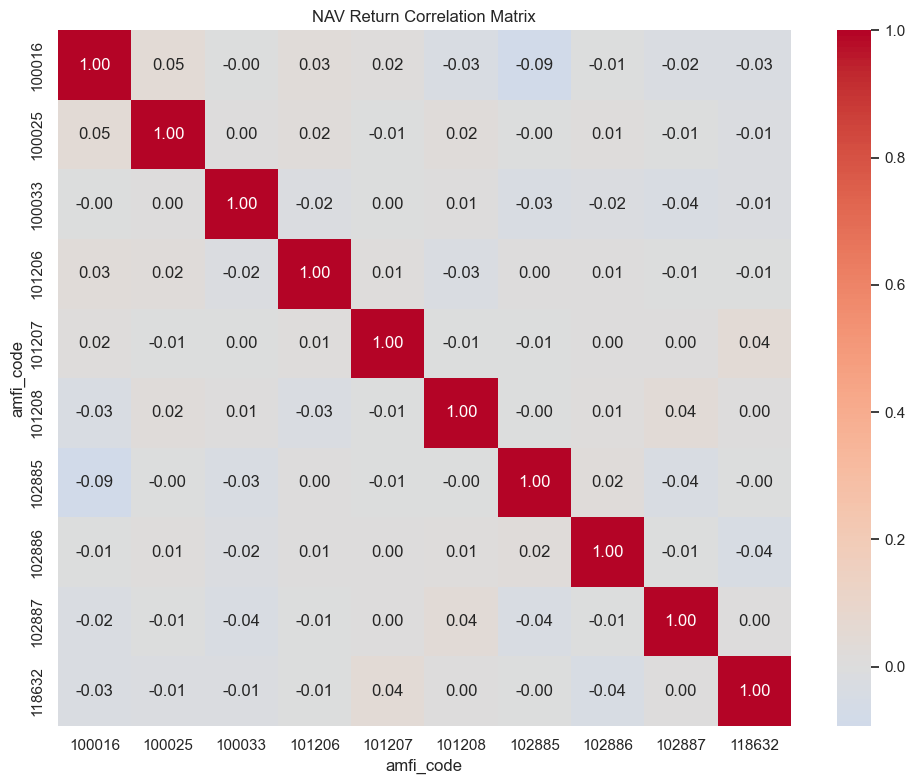

In [60]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')

plt.tight_layout()

plt.savefig(
    '../report/nav_correlation_matrix.png',
    bbox_inches='tight'
)

plt.show()

### Insight 11: NAV Return Correlation Analysis

The selected mutual funds exhibit generally low return correlations, with most correlation coefficients remaining close to zero. This suggests a relatively diversified set of funds where performance movements are not strongly dependent on one another. Low correlation among funds can help investors reduce portfolio risk through diversification.

In [61]:
df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
print(df.columns)
df.head()



Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
sector_weights = (
    df.groupby("sector")["weight_pct"]
      .sum()
      .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

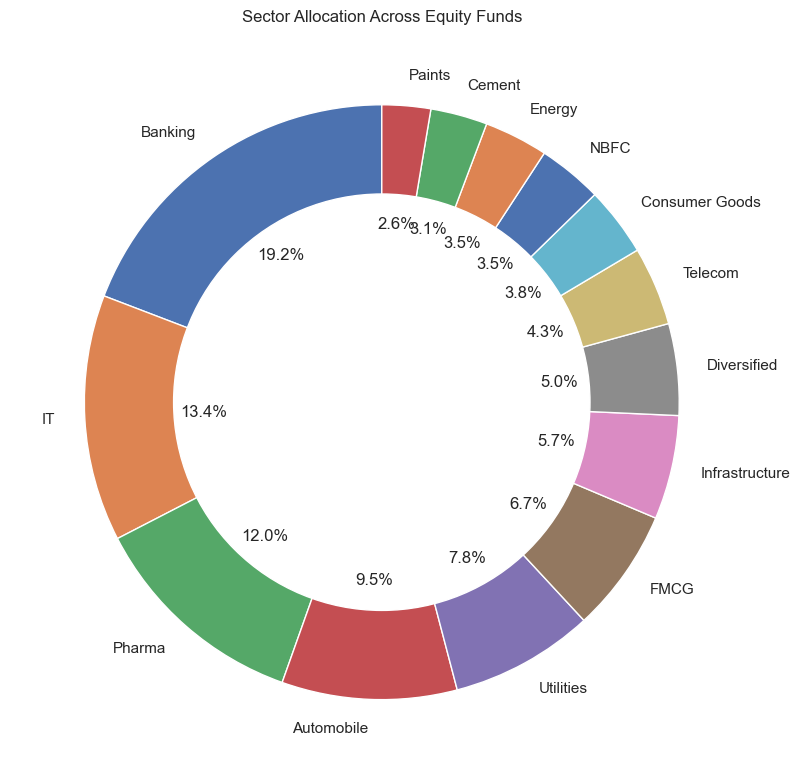

In [74]:
sector_weights = (
    df.groupby('sector')['weight_pct']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')

plt.tight_layout()

plt.savefig(
    '../report/sector_allocation_donut.png',
    bbox_inches='tight'
)

plt.show()


### Insight 12: Sector Allocation Across Equity Funds

Banking, Utilities, Pharma, and Diversified sectors account for a significant portion of the portfolio allocation. This indicates that fund managers are concentrating investments in sectors with strong growth potential and market relevance, while maintaining diversification across multiple industries.